In [1]:
from SCFT_functions import *
from DNA_input import *

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from numba import njit, prange
from matplotlib.colors import LogNorm

Using cupy


In [3]:
def downsample_classes_nearest(classes, new_size, *, align="centers", dtype=None):
    """
    Nearest-neighbor resample of a 1D class-label array to a new length.

    Parameters
    ----------
    classes : array_like, shape (n,)
        Integer (or categorical) labels per index.
    new_size : int
        Target length.
    align : {"centers", "edges"}
        - "centers": map new bin centers to old indices (usually best for down/up-sampling)
        - "edges": map linearly from [0, n-1] to [0, new_size-1]
    dtype : numpy dtype or None
        Output dtype; defaults to input dtype.

    Returns
    -------
    out : np.ndarray, shape (new_size,)
        Resampled labels.
    """
    x = np.asarray(classes)
    n = x.size
    if n == 0:
        raise ValueError("classes must be non-empty")
    if new_size <= 0:
        raise ValueError("new_size must be a positive integer")
    if new_size == 1:
        return np.array([x[0]], dtype=(dtype or x.dtype))

    if align == "centers":
        # Map new sample centers to old sample centers.
        # t in [0,1): (i+0.5)/new_size; old index = t*n - 0.5
        t = (np.arange(new_size) + 0.5) / new_size
        idx = np.rint(t * n - 0.5).astype(int)
    elif align == "edges":
        # Map endpoints exactly: i=0 -> 0, i=new_size-1 -> n-1
        idx = np.rint(np.linspace(0, n - 1, new_size)).astype(int)
    else:
        raise ValueError("align must be 'centers' or 'edges'")

    idx = np.clip(idx, 0, n - 1)
    out = x[idx]
    return out.astype(dtype or x.dtype, copy=False)

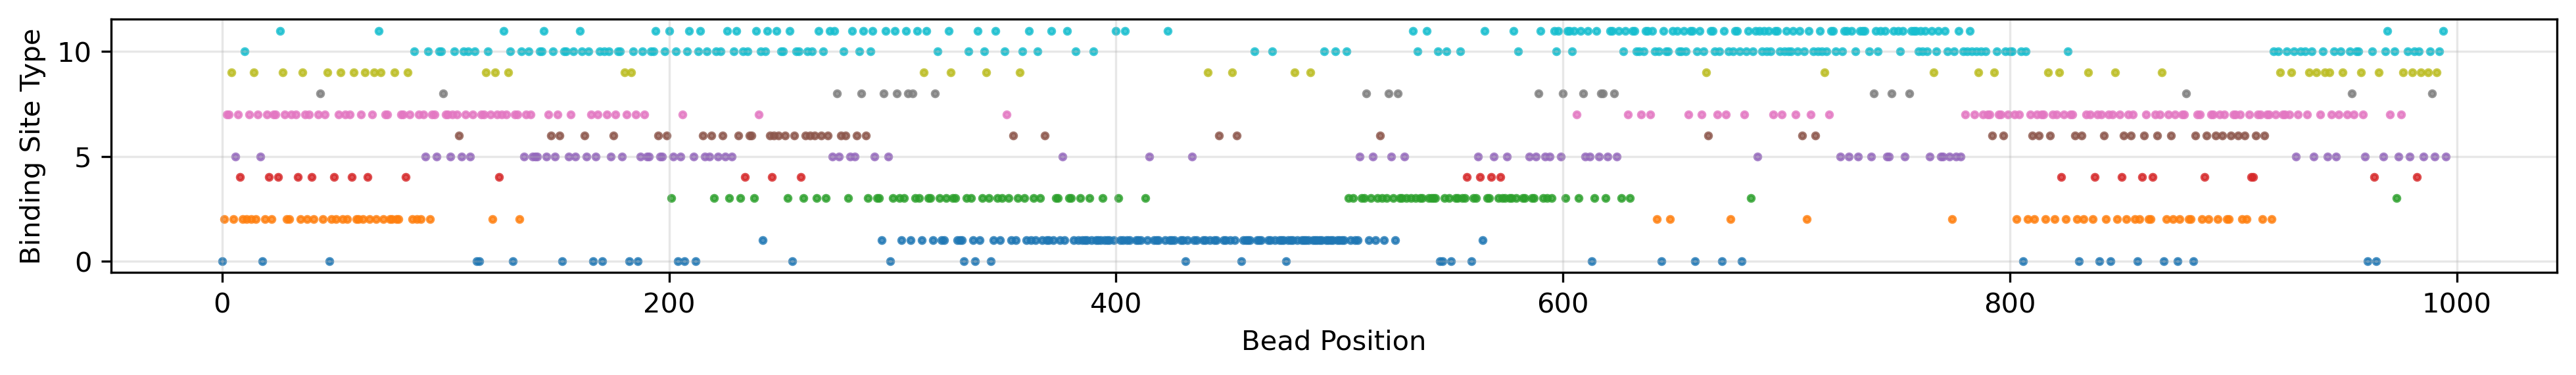

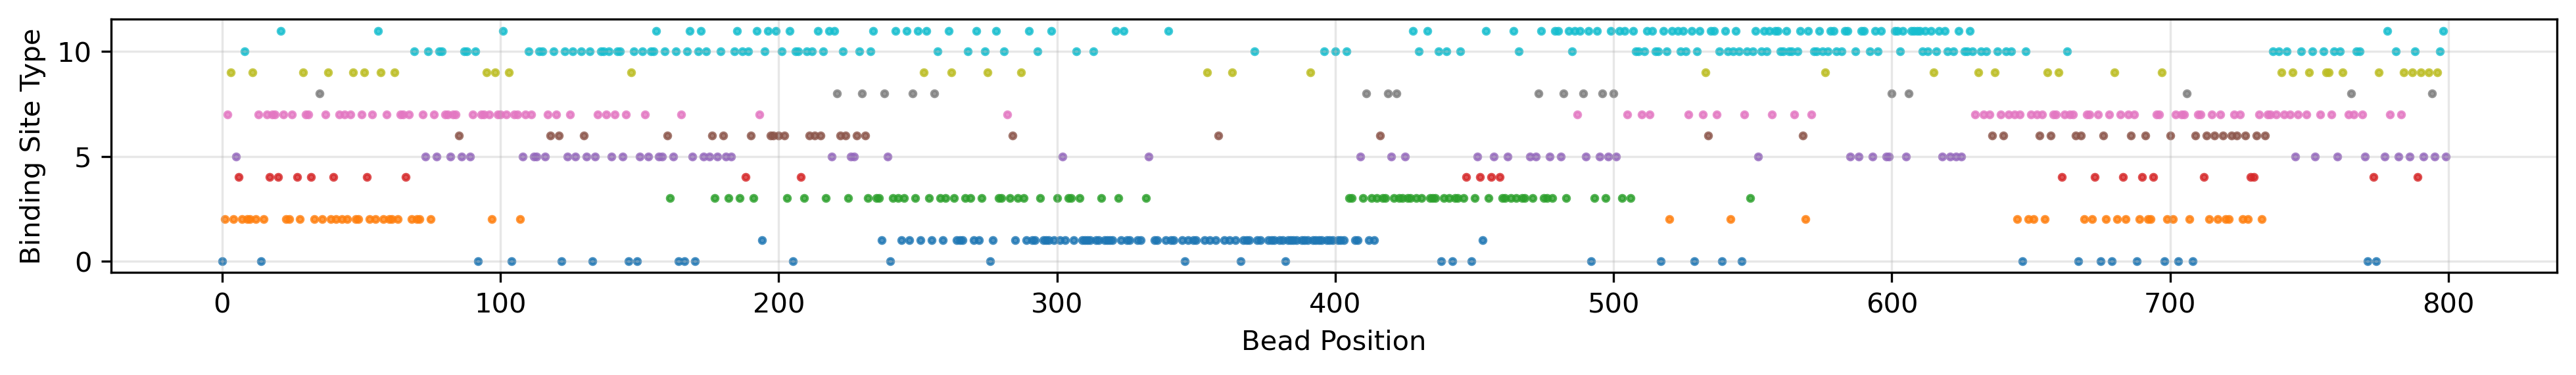

[0.1075  0.06875 0.095   0.03    0.085   0.05375 0.1325  0.02375 0.05
 0.15125 0.10875 0.09375]


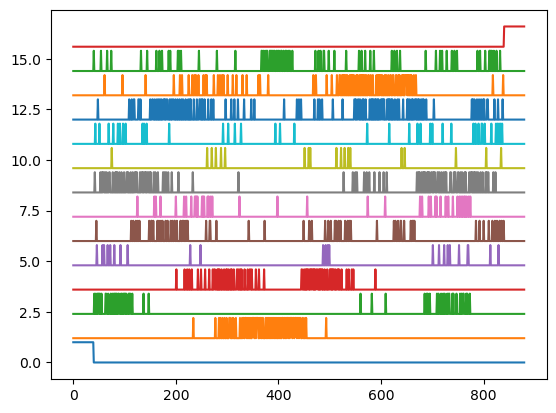

[1. 1. 1. 1. 0. 1. 0. 1. 0. 0. 1. 1.]
(12,)
[0. 1. 1. 1. 1. 0. 1. 0. 1. 0. 0. 1. 1. 0.]
879


In [4]:
infered_sequence = np.load("../Bead_sequence_MC/IMR90_infer_sequence_30_42.npy")
visualize_config(infered_sequence, np.max(infered_sequence))

infered_sequence_downsample = downsample_classes_nearest(infered_sequence, 800)
visualize_config(infered_sequence_downsample, np.max(infered_sequence))
infered_sequence = infered_sequence_downsample

chain_interaction_binary = colors_to_onehot(infered_sequence)
#ns = chain_interaction_binary.shape[1]-1
plt.show()

print(np.mean(chain_interaction_binary, axis = 1))
extra_length = 40
chain_interaction_binary_temp = np.zeros((chain_interaction_binary.shape[0]+2,chain_interaction_binary.shape[1]+2*extra_length))
chain_interaction_binary_temp[1:-1,extra_length:-extra_length] = chain_interaction_binary
chain_interaction_binary_temp[0, 0:extra_length] = 1
chain_interaction_binary_temp[-1, -extra_length:] = 1

ns = chain_interaction_binary_temp.shape[1]-1

for i in range(chain_interaction_binary_temp.shape[0]):
    plt.plot(chain_interaction_binary_temp[i]+i*1.2)
plt.show()

AB_binding_class_epigenetics = np.load("AB_binding_class_epigenetics.npy")
print(AB_binding_class_epigenetics)
print(AB_binding_class_epigenetics.shape)

AB_binding_class_epigenetics_temp = np.zeros(AB_binding_class_epigenetics.shape[0]+2)
AB_binding_class_epigenetics_temp[1:-1] = AB_binding_class_epigenetics
print(AB_binding_class_epigenetics_temp)

print(ns)

In [5]:
N = 150
Nseg = 1

PP = 475
PS = 350

chi_pp = PP*xp.ones((AB_binding_class_epigenetics_temp.shape[0],AB_binding_class_epigenetics_temp.shape[0]))
chi_ps = PS*xp.ones(AB_binding_class_epigenetics_temp.shape[0])

chi_offset = 10

for i in range(AB_binding_class_epigenetics_temp.shape[0]):
    if AB_binding_class_epigenetics_temp[i]==0: # B
        chi_ps[i] = PS+chi_offset
    else: # A
        chi_ps[i] = PS-chi_offset
    for j in range(AB_binding_class_epigenetics_temp.shape[0]):
        if (AB_binding_class_epigenetics_temp[i]==0) ^ (AB_binding_class_epigenetics_temp[j]==0):
            chi_pp[i, j] = PP+chi_offset
        elif AB_binding_class_epigenetics_temp[i]==1 and AB_binding_class_epigenetics_temp[j]==1:
            chi_pp[i, j] = PP-chi_offset

end_interaction_strength_ps = PS+50
end_interaction_strength_pp = PP+50

chi_ps[0] = end_interaction_strength_ps
chi_ps[-1] = end_interaction_strength_ps

chi_pp[0, :] = end_interaction_strength_pp
chi_pp[-1, :] = end_interaction_strength_pp
chi_pp[:, 0] = end_interaction_strength_pp
chi_pp[:, -1] = end_interaction_strength_pp

print(chi_pp)
print(chi_ps)

N = 200
Nseg = 1

L = 30 #dimension of the box

ns = chain_interaction_binary_temp.shape[1]-1

nx = ny = nz = 64
#initial_qsr = np.ones((nx, ny, nz))
initial_qsr = xp.random.rand(nx,ny,nz)

polymer = Scft(
    N = N,
    Lx=L, Ly=L,
    phibar=0.15, # volume fraction of polymer
    l_p=np.sqrt(N),
    n_seg=Nseg, # contour length of polymer normalized from 0-1
    nx=nx, ny=ny,
    ns=ns,
    iterations=10000,
    error_tol=1e-12,
    chain_interaction=chain_interaction_binary_temp,
    self_avoiding=0,
    initial_qsr=initial_qsr / np.mean(initial_qsr),
    mixing_rate=0.01,
    chi_polymer_block = chi_pp,
    chi_polymer_s = chi_ps,
    PB = 1,
    close_boundary=True,
    D3 = True,
    Lz = L,
    nz = nz
)

[[525. 525. 525. 525. 525. 525. 525. 525. 525. 525. 525. 525. 525. 525.]
 [525. 465. 465. 465. 465. 485. 465. 485. 465. 485. 485. 465. 465. 525.]
 [525. 465. 465. 465. 465. 485. 465. 485. 465. 485. 485. 465. 465. 525.]
 [525. 465. 465. 465. 465. 485. 465. 485. 465. 485. 485. 465. 465. 525.]
 [525. 465. 465. 465. 465. 485. 465. 485. 465. 485. 485. 465. 465. 525.]
 [525. 485. 485. 485. 485. 475. 485. 475. 485. 475. 475. 485. 485. 525.]
 [525. 465. 465. 465. 465. 485. 465. 485. 465. 485. 485. 465. 465. 525.]
 [525. 485. 485. 485. 485. 475. 485. 475. 485. 475. 475. 485. 485. 525.]
 [525. 465. 465. 465. 465. 485. 465. 485. 465. 485. 485. 465. 465. 525.]
 [525. 485. 485. 485. 485. 475. 485. 475. 485. 475. 475. 485. 485. 525.]
 [525. 485. 485. 485. 485. 475. 485. 475. 485. 475. 475. 485. 485. 525.]
 [525. 465. 465. 465. 465. 485. 465. 485. 465. 485. 485. 465. 465. 525.]
 [525. 465. 465. 465. 465. 485. 465. 485. 465. 485. 485. 465. 465. 525.]
 [525. 525. 525. 525. 525. 525. 525. 525. 525. 525.

In [6]:
wsr, qsr_initial, qsr_d_initial, diff, free_energy_hist = initialization(polymer, seed = 5, shift = 0)

In [7]:
polymer.iterations = 10000
wsr, phi, phi_blocks, qsr, qsr_d, diff, free_energy_hist = scft_loop(polymer, wsr, qsr_initial, qsr_d_initial, diff, free_energy_hist, polymer_loop=True)

np.savez("3D_chi_AB.npz", wsr = wsr, phi = phi, phi_blocks = phi_blocks, qsr = qsr, qsr_d = qsr_d, diff = diff, free_energy_hist = free_energy_hist)

100%|██████████| 10000/10000 [7:15:28<00:00,  2.61s/it] 


In [ ]:
def save_np(wsr, phi, phi_blocks, qsr_initial, qsr_d_initial, diff):
    arrs = {
            "wsr": to_numpy(wsr),
            "phi": to_numpy(phi),
            "phi_blocks": to_numpy(phi_blocks),
            "qsr_initial": to_numpy(qsr_initial),
            "qsr_d_initial": to_numpy(qsr_d_initial),
            "diff": to_numpy(diff),
            "free_energy_hist": to_numpy(free_energy_hist),
        }

    np.savez("polymer3d.npz", arrs=arrs)
    return

save_np(wsr, phi, phi_blocks, qsr_initial, qsr_d_initial, diff)

40.95841945603324


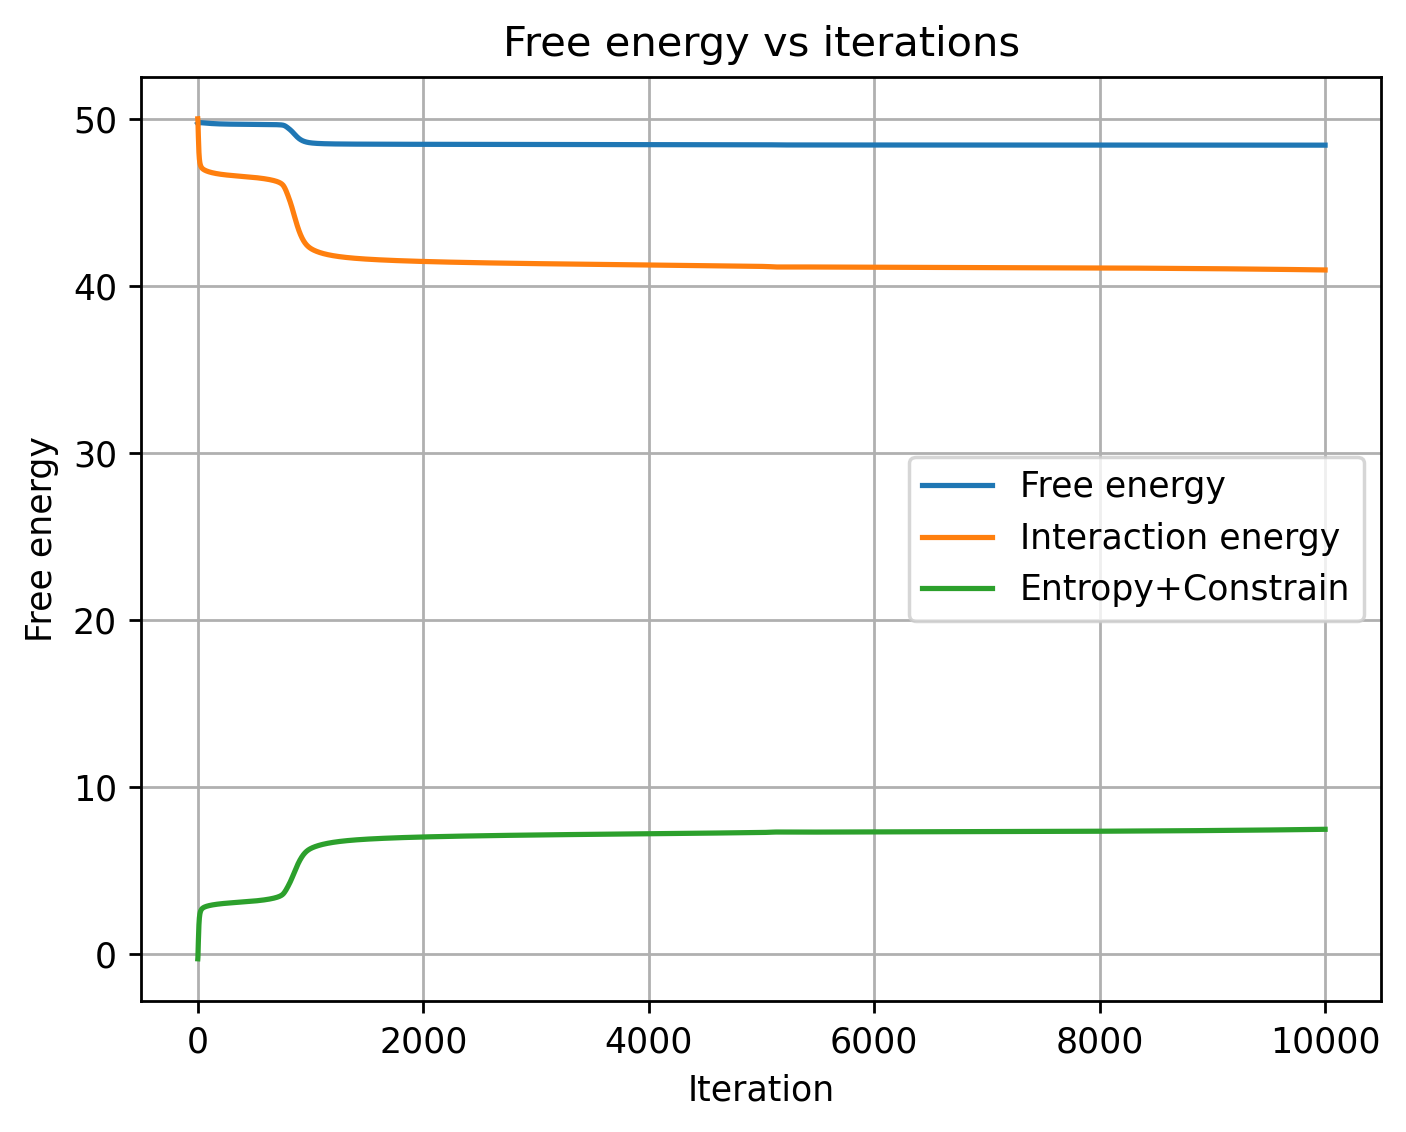

In [8]:
plt.figure(dpi=250)
free_energy_hist_plot = np.array(free_energy_hist)
plt.plot(free_energy_hist_plot[:, 0],label="Free energy")
plt.plot(free_energy_hist_plot[:, 1],label="Interaction energy")
plt.plot(free_energy_hist_plot[:, 2],label="Entropy+Constrain")
#plt.yscale('log')
plt.title("Free energy vs iterations")
plt.ylabel("Free energy")
plt.xlabel("Iteration")
plt.legend()
plt.grid()
print(free_energy_hist[-1][1])

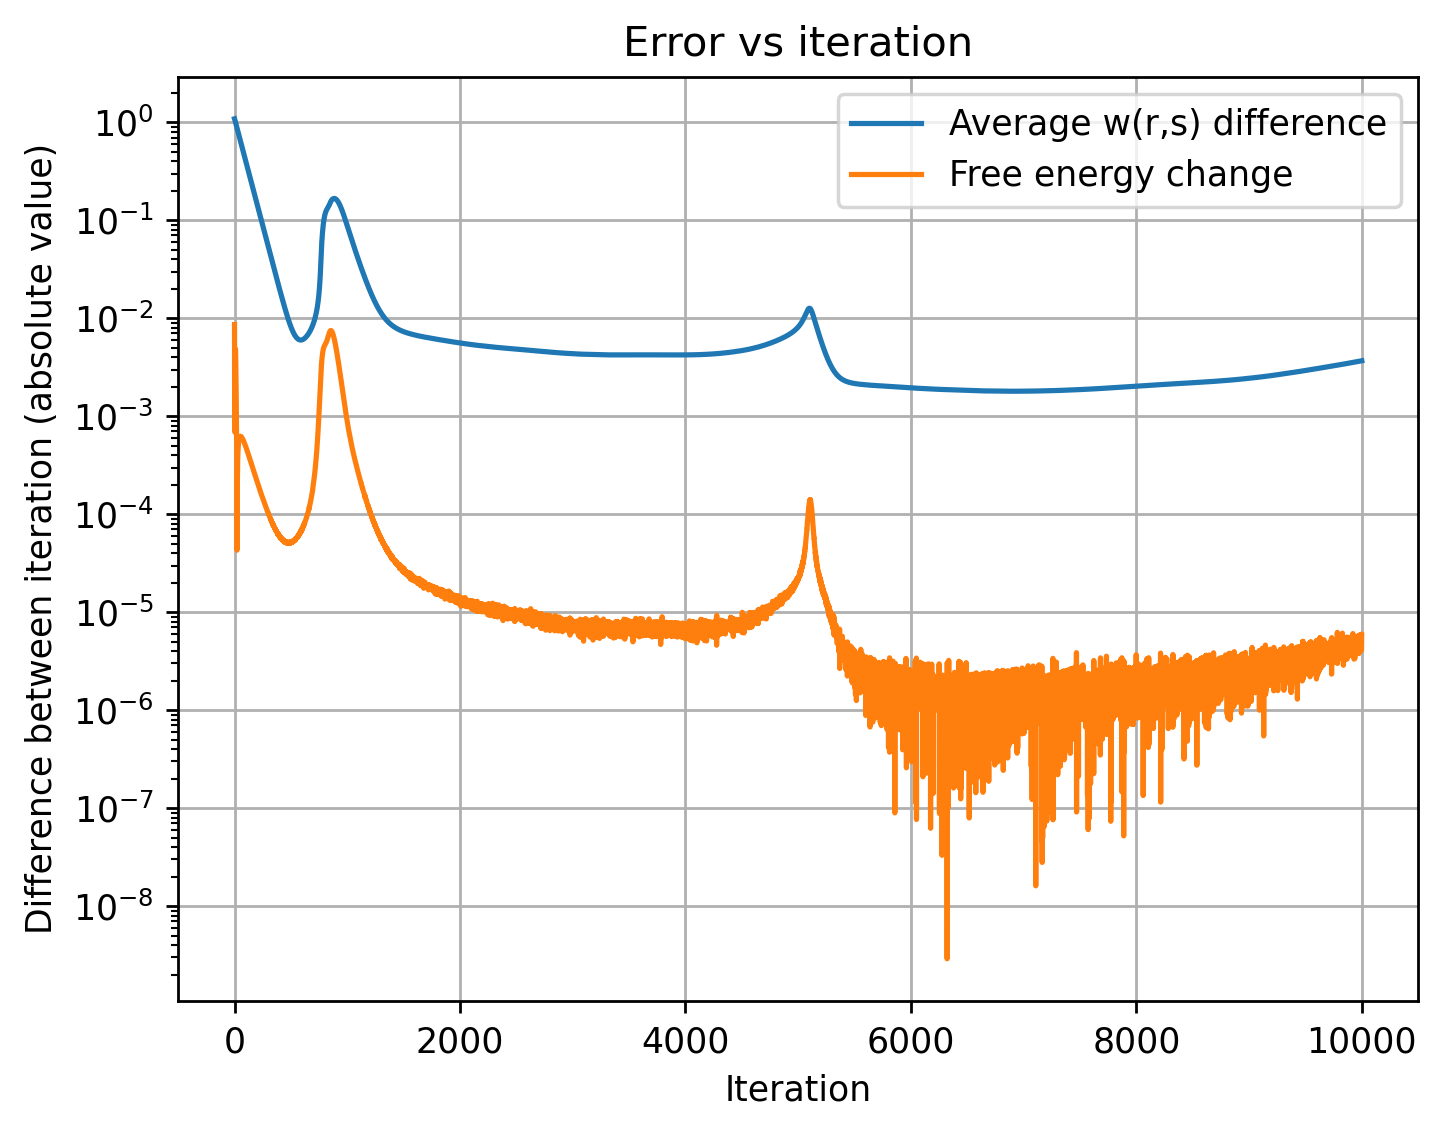

In [9]:
plt.figure(dpi=250)
plt.plot(diff, label="Average w(r,s) difference")
diff_energy = free_energy_hist_plot[1:, 0]-free_energy_hist_plot[:-1, 0]
plt.plot(abs(diff_energy), label="Free energy change")
plt.yscale('log')
#plt.title("Average difference in w(r,s) per iteration")
plt.title("Error vs iteration")
plt.ylabel("Difference between iteration (absolute value)")
plt.xlabel("Iteration")
plt.grid()
plt.legend()

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import measure
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def plot_multi_isosurface(densities, threshold_ratio=0.8, alpha=0.6, colormap='tab10'):
    """
    Plot isosurfaces for multiple 3D density arrays on the same axes.

    Parameters:
    - densities: list or array of shape (m, nx, ny, nz), where each element is a 3D density grid
    - threshold_ratio: float between 0 and 1; isosurface at this fraction of each component's max
    - alpha: float for surface transparency
    - colormap: name of a matplotlib colormap for distinct colors
    """
    # Ensure list of 3D arrays
    comps = list(densities)
    m = len(comps)
    cmap = plt.cm.get_cmap(colormap, m)

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    for i, density in enumerate(comps):
        level = threshold_ratio * density.max()
        verts, faces, normals, values = measure.marching_cubes(density, level=level)
        mesh = Poly3DCollection(verts[faces], alpha=alpha)
        mesh.set_facecolor(cmap(i))
        ax.add_collection3d(mesh)

    # Set axes limits based on the first component
    nx, ny, nz = comps[0].shape
    ax.set_xlim(0, nx)
    ax.set_ylim(0, ny)
    ax.set_zlim(0, nz)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    plt.tight_layout()
    plt.show()

    return

C:\Users\19162\AppData\Local\Temp\ipykernel_58584\582000932.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(colormap, m)


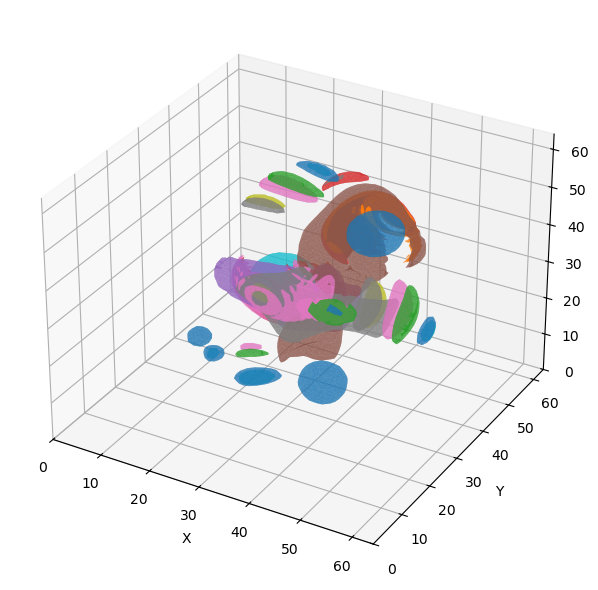

In [12]:
plot_multi_isosurface(to_numpy(phi_blocks), threshold_ratio=0.90)

In [13]:
import plotly.graph_objects as go

def plot_isosurfaces(
    density,
    top_fraction: float = 0.10,
    spacing=(1.0, 1.0, 1.0),
    component_names=None,
    save_html_path=None,
):
    vol = to_numpy(density)
    assert vol.ndim == 4, f"Expected (m, nx, ny, nz), got shape {vol.shape}"
    m, nx, ny, nz = vol.shape
    sx, sy, sz = spacing

    if component_names is None:
        component_names = [f"component {i}" for i in range(m)]
    else:
        assert len(component_names) == m, "component_names must match m"

    fig = go.Figure()

    for i in range(m):
        field = vol[i].astype(np.float64, copy=False)
        flat = field.ravel()
        nonzero = flat[flat > 0]
        base = nonzero if nonzero.size > 0 else flat
        if base.size == 0:
            continue

        iso_level = float(np.quantile(base, 1.0 - top_fraction))

        # Marching cubes at the chosen iso-level
        try:
            verts, faces, normals, values = measure.marching_cubes(
                volume=field, level=iso_level, spacing=(sx, sy, sz)
            )
        except TypeError:
            verts, faces, normals, values = measure.marching_cubes_lewiner(
                field, level=iso_level, spacing=(sx, sy, sz)
            )

        if verts.size == 0 or faces.size == 0:
            continue

        mesh = go.Mesh3d(
            x=verts[:, 0], y=verts[:, 1], z=verts[:, 2],
            i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
            name=component_names[i],
            opacity=0.5,
            flatshading=True,
            showscale=False,
        )
        fig.add_trace(mesh)

    fig.update_layout(
        title="Polymer components: densest-region iso-surfaces",
        scene=dict(xaxis_title="x", yaxis_title="y", zaxis_title="z", aspectmode="data"),
        showlegend=True,
    )

    if save_html_path is not None:
        fig.write_html(save_html_path, include_plotlyjs="cdn")
        return save_html_path
    return fig

In [16]:
plot_isosurfaces(
    to_numpy(phi_blocks),                 # shape (m, nx, ny, nz)
    top_fraction=0.02,       # densest fraction to enclose as an iso-surface
    spacing=(polymer.dx, polymer.dy, polymer.dz),    # voxel spacing for proper aspect ratio
    component_names=None,    # optional list of names per component
    save_html_path='isosurface_demo.html',     # optional: path to save interactive HTML
)

'isosurface_demo.html'

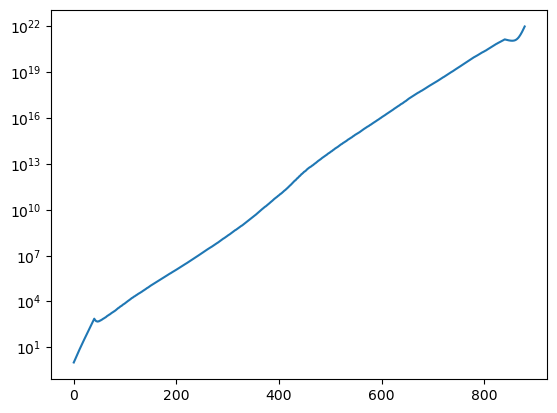

In [15]:
qsr_decay = np.mean(qsr, axis = (1,2,3))
plt.plot(to_numpy(qsr_decay))
plt.yscale('log')

In [19]:
@njit(parallel=True)
def pair_correlation_2D(rho):
    ns_plus_1 = rho.shape[0]
    correlation_function = np.zeros((ns_plus_1, ns_plus_1))

    #rho = rho/np.mean(rho, axis = (1,2))[:, None, None]
    rho = rho/np.mean(rho)

    for i in prange(ns_plus_1):
        for k in prange(ns_plus_1):
            correlation_function[i, k] = np.sum(rho[i] * rho[k])

    return correlation_function / (rho.shape[1]*rho.shape[2])

In [20]:
corr_3d = pair_correlation_2D(to_numpy(qsr*qsr_d))

Text(0.5, 1.0, 'SCFT contact map IMR90 Chr21 30-42 Mb')

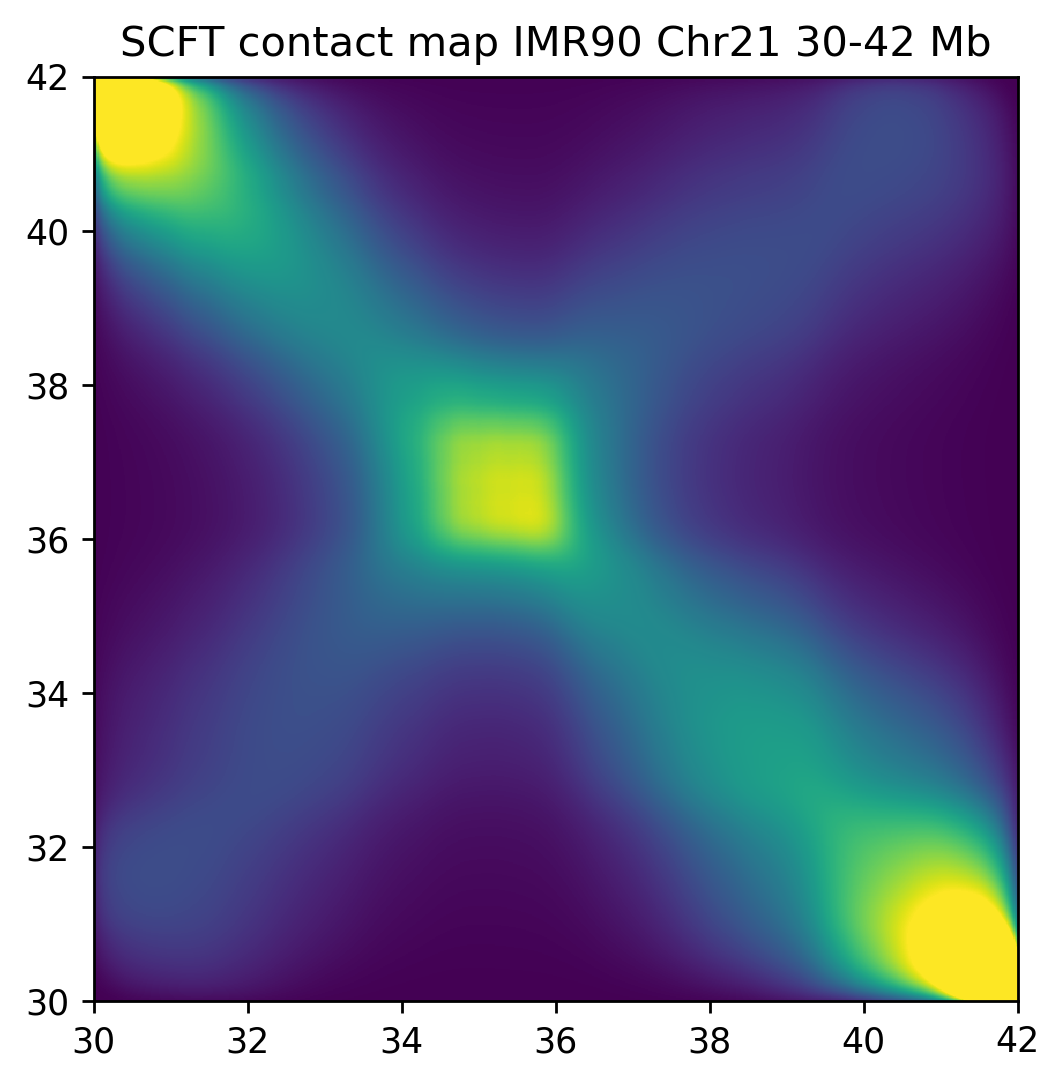

In [31]:
plt.figure(dpi = 250)
crop_length = extra_length
corr_3d_crop = corr_3d[crop_length:-crop_length, crop_length:-crop_length]
dynamic_range = 3.5 * np.std(corr_3d_crop)
extent = (30,42,30,42)
plt.imshow(corr_3d_crop, cmap='viridis', interpolation='nearest', aspect=1,extent=extent,
           #vmin=-dynamic_range,
           vmax=+dynamic_range
           )

#plt.colorbar()
plt.title("SCFT contact map IMR90 Chr21 30-42 Mb")

In [47]:

def _threshold_by_density_quantile(field, top_fraction):
    flat = field.ravel()
    nonzero = flat[flat > 0]
    base = nonzero if nonzero.size > 0 else flat
    if base.size == 0:
        return None
    return float(np.quantile(base, 1.0 - top_fraction))


def _threshold_by_mass_fraction(field, top_mass_fraction):
    """Return value t so that voxels >= t contain ~top_mass_fraction of total mass."""
    f = field.astype(np.float64, copy=False).ravel()
    f = f[f > 0]
    total = float(f.sum())
    if total <= 0 or f.size == 0:
        return None
    # Sort descending
    f_sorted = np.sort(f)[::-1]
    csum = np.cumsum(f_sorted)
    target = top_mass_fraction * total
    idx = int(np.searchsorted(csum, target, side="left"))
    if idx >= f_sorted.size:
        idx = f_sorted.size - 1
    return float(f_sorted[idx])


def _connected_component_centers(
    field_3d: np.ndarray,
    top_fraction: float = 0.10,
    spacing=(1.0, 1.0, 1.0),
    connectivity: int = 1,
    min_voxels: int = 10,
    threshold_mode: str = "density",  # "density" or "mass_fraction"
):
    field = np.asarray(field_3d, dtype=np.float64)

    if threshold_mode == "mass_fraction":
        thr = _threshold_by_mass_fraction(field, top_fraction)
    else:
        thr = _threshold_by_density_quantile(field, top_fraction)

    if thr is None:
        return np.zeros((0, 3), dtype=float), np.zeros((0,), dtype=int)

    mask = field >= thr
    labels = measure.label(mask, connectivity=connectivity)
    nlab = int(labels.max())
    if nlab == 0:
        return np.zeros((0, 3), dtype=float), np.zeros((0,), dtype=int)

    sx, sy, sz = spacing
    centers, sizes = [], []
    for lab in range(1, nlab + 1):
        idx = np.argwhere(labels == lab)
        nvox = idx.shape[0]
        if nvox < min_voxels:
            continue
        weights = field[labels == lab].astype(np.float64, copy=False)
        wsum = float(weights.sum())
        if wsum <= 0:
            c_idx = idx.mean(axis=0)
        else:
            c_idx = (idx * weights[:, None]).sum(axis=0) / wsum
        centers.append([c_idx[0] * sx, c_idx[1] * sy, c_idx[2] * sz])
        sizes.append(nvox)

    if len(centers) == 0:
        return np.zeros((0, 3), dtype=float), np.zeros((0,), dtype=int)
    return np.asarray(centers, dtype=float), np.asarray(sizes, dtype=int)


def plot_isosurfaces_with_contour_centers(
    density_components,              # (m, nx, ny, nz) -> iso-surfaces
    density_contour,                 # (ns, nx, ny, nz) -> dot centers per ns
    top_fraction_components: float = 0.10,
    top_fraction_contour: float = 0.10,
    spacing=(1.0, 1.0, 1.0),
    component_names=None,
    connectivity: int = 1,
    min_voxels: int = 10,
    max_slices=None,
    center_marker_size: int = 9,
    center_marker_color: str = "rgba(0,0,0,1)",
    threshold_mode_components: str = "density",      # "density" or "mass_fraction"
    threshold_mode_contour: str = "density",         # "density" or "mass_fraction"
    save_html_path=None,
):
    vol_m = to_numpy(density_components)
    vol_s = to_numpy(density_contour)

    if vol_m.ndim != 4:
        raise ValueError(f"density_components must be (m,nx,ny,nz), got {vol_m.shape}")
    if vol_s.ndim != 4:
        raise ValueError(f"density_contour must be (ns,nx,ny,nz), got {vol_s.shape}")

    m, nx, ny, nz = vol_m.shape
    ns, nx2, ny2, nz2 = vol_s.shape
    if (nx, ny, nz) != (nx2, ny2, nz2):
        raise ValueError("Spatial grid must match between density_components and density_contour.")

    if component_names is None:
        component_names = [f"component {i}" for i in range(m)]
    else:
        if len(component_names) != m:
            raise ValueError("component_names length must match m")

    sx, sy, sz = spacing
    fig = go.Figure()

    # --- iso-surfaces (per component), thresholded by chosen mode ---
    for i in range(m):
        field = vol_m[i].astype(np.float64, copy=False)

        if threshold_mode_components == "mass_fraction":
            iso_level = _threshold_by_mass_fraction(field, top_fraction_components)
        else:
            iso_level = _threshold_by_density_quantile(field, top_fraction_components)

        if iso_level is None:
            continue

        try:
            verts, faces, normals, values = measure.marching_cubes(
                volume=field, level=iso_level, spacing=(sx, sy, sz)
            )
        except TypeError:
            verts, faces, normals, values = measure.marching_cubes_lewiner(
                field, level=iso_level, spacing=(sx, sy, sz)
            )

        if verts.size == 0 or faces.size == 0:
            continue

        fig.add_trace(
            go.Mesh3d(
                x=verts[:, 0], y=verts[:, 1], z=verts[:, 2],
                i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
                name=component_names[i] + (
                    " (mass fraction)" if threshold_mode_components == "mass_fraction" else " (density quantile)"
                ),
                opacity=0.5,
                flatshading=True,
                showscale=False,
            )
        )

    # --- centers along ns, thresholded by chosen mode ---
    if max_slices is not None and ns > int(max_slices) and int(max_slices) > 0:
        stride = int(np.ceil(ns / float(max_slices)))
        ns_indices = np.arange(0, ns, stride, dtype=int)
    else:
        ns_indices = np.arange(ns, dtype=int)

    centers_list = []
    hover_list = []

    for s in ns_indices:
        centers, sizes = _connected_component_centers(
            vol_s[s],
            top_fraction=top_fraction_contour,
            spacing=spacing,
            connectivity=connectivity,
            min_voxels=min_voxels,
            threshold_mode=threshold_mode_contour,
        )
        if centers.shape[0] == 0:
            continue
        centers_list.append(centers)
        for k, nvox in enumerate(sizes.tolist()):
            hover_list.append(
                f"ns={int(s)}; region={k+1}; voxels={int(nvox)}; mode={threshold_mode_contour}"
            )

    if len(centers_list) > 0:
        C = np.vstack(centers_list)
        fig.add_trace(
            go.Scatter3d(
                x=C[:, 0], y=C[:, 1], z=C[:, 2],
                mode="markers",
                name="centers (per ns)",
                marker=dict(size=int(center_marker_size), color=center_marker_color, opacity=1.0),
                text=hover_list,
                hoverinfo="text",
            )
        )

    fig.update_layout(
        title="Iso-surfaces (components) + centers along ns (supports density or mass-fraction thresholding)",
        scene=dict(xaxis_title="x", yaxis_title="y", zaxis_title="z", aspectmode="data"),
        showlegend=True,
    )

    if save_html_path is not None:
        fig.write_html(save_html_path, include_plotlyjs="cdn")
        return fig, save_html_path
    return fig, None


# ------------------------------
# Demo using mass-fraction iso-surfaces for (m, ...) and density-quantile for ns dots
# ------------------------------
def make_two_adjacent_gaussians_m(nx=64, ny=64, nz=64, extent=6.0, sep=2.0, sigma=0.8):
    x = np.linspace(-extent / 2, extent / 2, nx)
    y = np.linspace(-extent / 2, extent / 2, ny)
    z = np.linspace(-extent / 2, extent / 2, nz)
    X, Y, Z = np.meshgrid(x, y, z, indexing="ij")

    def gauss(cx, cy, cz):
        r2 = ((X - cx) ** 2 + (Y - cy) ** 2 + (Z - cz) ** 2) / (2.0 * sigma ** 2)
        g = np.exp(-r2)
        g /= g.sum()
        return g

    g1 = gauss(-sep / 2, 0.0, 0.0)
    g2 = gauss(+sep / 2, 0.0, 0.0)
    spacing = (x[1] - x[0], y[1] - y[0], z[1] - z[0])
    return np.stack([g1, g2], axis=0), spacing


def make_contour_gaussian_path_ns(ns=40, nx=64, ny=64, nz=64, extent=6.0, sigma=0.6):
    x = np.linspace(-extent / 2, extent / 2, nx)
    y = np.linspace(-extent / 2, extent / 2, ny)
    z = np.linspace(-extent / 2, extent / 2, nz)
    X, Y, Z = np.meshgrid(x, y, z, indexing="ij")

    xs = np.linspace(-extent * 0.25, extent * 0.25, ns)
    out = np.empty((ns, nx, ny, nz), dtype=np.float64)
    for s, cx in enumerate(xs):
        r2 = ((X - cx) ** 2 + Y**2 + Z**2) / (2.0 * sigma ** 2)
        g = np.exp(-r2)
        g /= g.sum()
        out[s] = g
    spacing = (x[1] - x[0], y[1] - y[0], z[1] - z[0])
    return out, spacing





In [51]:
fig, saved = plot_isosurfaces_with_contour_centers(
    density_components=to_numpy(phi_blocks),
    density_contour=to_numpy(qsr*qsr_d),
    threshold_mode_components="mass_fraction",
    top_fraction_components=0.07,
    threshold_mode_contour="mass_fraction",
    top_fraction_contour=0.3,
    connectivity=1,
    min_voxels=20,
    #max_slices=None,
    center_marker_size=9,                 # larger
    center_marker_color="rgba(0,0,0,1)",
    save_html_path='isosurface_IMR90.html',
)

In [55]:
def _threshold_by_density_quantile(field, top_fraction):
    flat = field.ravel()
    nonzero = flat[flat > 0]
    base = nonzero if nonzero.size > 0 else flat
    if base.size == 0:
        return None
    return float(np.quantile(base, 1.0 - top_fraction))


def _threshold_by_mass_fraction(field, top_mass_fraction):
    f = field.astype(np.float64, copy=False).ravel()
    f = f[f > 0]
    total = float(f.sum())
    if total <= 0 or f.size == 0:
        return None
    f_sorted = np.sort(f)[::-1]
    csum = np.cumsum(f_sorted)
    target = top_mass_fraction * total
    idx = int(np.searchsorted(csum, target, side="left"))
    if idx >= f_sorted.size:
        idx = f_sorted.size - 1
    return float(f_sorted[idx])


def _connected_component_centers(
    field_3d: np.ndarray,
    top_fraction: float = 0.10,
    spacing=(1.0, 1.0, 1.0),
    connectivity: int = 1,
    min_voxels: int = 10,
    threshold_mode: str = "density",
):
    field = np.asarray(field_3d, dtype=np.float64)

    if threshold_mode == "mass_fraction":
        thr = _threshold_by_mass_fraction(field, top_fraction)
    else:
        thr = _threshold_by_density_quantile(field, top_fraction)

    if thr is None:
        return np.zeros((0, 3), dtype=float), np.zeros((0,), dtype=int)

    mask = field >= thr
    labels = measure.label(mask, connectivity=connectivity)
    nlab = int(labels.max())
    if nlab == 0:
        return np.zeros((0, 3), dtype=float), np.zeros((0,), dtype=int)

    sx, sy, sz = spacing
    centers, sizes = [], []
    for lab in range(1, nlab + 1):
        idx = np.argwhere(labels == lab)
        nvox = idx.shape[0]
        if nvox < min_voxels:
            continue
        weights = field[labels == lab].astype(np.float64, copy=False)
        wsum = float(weights.sum())
        if wsum <= 0:
            c_idx = idx.mean(axis=0)
        else:
            c_idx = (idx * weights[:, None]).sum(axis=0) / wsum
        centers.append([c_idx[0] * sx, c_idx[1] * sy, c_idx[2] * sz])
        sizes.append(nvox)

    if len(centers) == 0:
        return np.zeros((0, 3), dtype=float), np.zeros((0,), dtype=int)
    return np.asarray(centers, dtype=float), np.asarray(sizes, dtype=int)


def plot_isosurfaces_with_centers_ui(
    density_components,              # (m, nx, ny, nz) -> iso-surfaces
    density_contour,                 # (ns, nx, ny, nz) -> dot centers per ns
    spacing=(1.0, 1.0, 1.0),
    component_names=None,
    # thresholding
    threshold_mode_components="mass_fraction",   # "density" or "mass_fraction"
    top_fraction_components=0.10,
    threshold_mode_contour="density",
    top_fraction_contour=0.10,
    # morphology
    connectivity=1,
    min_voxels=10,
    max_slices=None,
    # dot styling
    dot_size=12,
    save_html_path=None,
):
    vol_m = to_numpy(density_components)
    vol_s = to_numpy(density_contour)
    m, nx, ny, nz = vol_m.shape
    ns, nx2, ny2, nz2 = vol_s.shape
    assert (nx, ny, nz) == (nx2, ny2, nz2)

    if component_names is None:
        component_names = [f"component {i}" for i in range(m)]

    sx, sy, sz = spacing
    fig = go.Figure()

    mesh_trace_idxs = []

    # --- mesh iso-surfaces ---
    for i in range(m):
        field = vol_m[i].astype(np.float64, copy=False)
        if threshold_mode_components == "mass_fraction":
            iso_level = _threshold_by_mass_fraction(field, top_fraction_components)
        else:
            iso_level = _threshold_by_density_quantile(field, top_fraction_components)
        if iso_level is None:
            continue

        try:
            verts, faces, normals, values = measure.marching_cubes(
                volume=field, level=iso_level, spacing=(sx, sy, sz)
            )
        except TypeError:
            verts, faces, normals, values = measure.marching_cubes_lewiner(
                field, level=iso_level, spacing=(sx, sy, sz)
            )
        if verts.size == 0 or faces.size == 0:
            continue

        mesh_trace_idxs.append(len(fig.data))
        fig.add_trace(
            go.Mesh3d(
                x=verts[:, 0], y=verts[:, 1], z=verts[:, 2],
                i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
                name=component_names[i],
                opacity=0.5,         # default semi-transparent
                flatshading=True,
                showscale=False,
            )
        )

    # --- centers along ns (black dots with outline) ---
    if max_slices is not None and ns > int(max_slices) and int(max_slices) > 0:
        stride = int(np.ceil(ns / float(max_slices)))
        ns_indices = np.arange(0, ns, stride, dtype=int)
    else:
        ns_indices = np.arange(ns, dtype=int)

    centers_list, hover_list = [], []
    for s in ns_indices:
        centers, sizes = _connected_component_centers(
            vol_s[s],
            top_fraction=top_fraction_contour,
            spacing=spacing,
            connectivity=connectivity,
            min_voxels=min_voxels,
            threshold_mode=threshold_mode_contour,
        )
        if centers.shape[0] == 0:
            continue
        centers_list.append(centers)
        for k, nvox in enumerate(sizes.tolist()):
            hover_list.append(f"ns={int(s)}; region={k+1}; voxels={int(nvox)}")

    if len(centers_list) > 0:
        C = np.vstack(centers_list)
        # A thicker black outline to help visibility
        fig.add_trace(
            go.Scatter3d(
                x=C[:, 0], y=C[:, 1], z=C[:, 2],
                mode="markers",
                name="centers (per ns)",
                marker=dict(
                    size=int(dot_size),
                    color="rgba(0,0,0,1)",
                    opacity=1.0,
                    symbol="circle",
                    line=dict(color="rgba(0,0,0,1)", width=2),
                ),
                text=hover_list,
                hoverinfo="text",
            )
        )

    # UI: buttons to control surface opacity/visibility (so dots remain pure black)
    # Note: In WebGL 3D, colors behind semi-transparent surfaces will be blended by design.
    # These UI toggles provide quick ways to inspect dots as pure black.
    ntraces = len(fig.data)
    # Build masks for restyle
    mesh_mask = [False] * ntraces
    for idx in mesh_trace_idxs:
        mesh_mask[idx] = True

    fig.update_layout(
        title="Iso-surfaces + black centers (with UI toggles for surface opacity)",
        scene=dict(xaxis_title="x", yaxis_title="y", zaxis_title="z", aspectmode="data"),
        showlegend=True,
        updatemenus=[
            dict(
                type="buttons",
                direction="right",
                x=0.0, y=1.10,
                buttons=[
                    dict(
                        label="Surfaces: Semi-transparent",
                        method="restyle",
                        args=[{"opacity": 0.5}, [i for i in range(ntraces) if i in mesh_trace_idxs]],
                    ),
                    dict(
                        label="Surfaces: Opaque",
                        method="restyle",
                        args=[{"opacity": 1.0}, [i for i in range(ntraces) if i in mesh_trace_idxs]],
                    ),
                    dict(
                        label="Surfaces: Hide",
                        method="restyle",
                        args=[{"visible": "legendonly"}, [i for i in range(ntraces) if i in mesh_trace_idxs]],
                    ),
                    dict(
                        label="Surfaces: Show",
                        method="restyle",
                        args=[{"visible": True}, [i for i in range(ntraces) if i in mesh_trace_idxs]],
                    ),
                ],
            )
        ],
    )

    if save_html_path is not None:
        fig.write_html(save_html_path, include_plotlyjs="cdn")
        return fig, save_html_path
    return fig, None


In [60]:
fig, saved = plot_isosurfaces_with_centers_ui(
    density_components=to_numpy(phi_blocks),
    density_contour=to_numpy(qsr*qsr_d),
    threshold_mode_components="mass_fraction",
    top_fraction_components=0.05,
    threshold_mode_contour="mass_fraction",
    top_fraction_contour=0.03,
    connectivity=1,
    min_voxels=20,
    #max_slices=None,
    #center_marker_size=9,                 # larger
    #center_marker_color="rgba(0,0,0,1)",
    dot_size=10,
    save_html_path='isosurface_IMR90.html',
)

(800,)
(14, 880)


In [74]:
inferred_sequence_downsample_temp = np.zeros(chain_interaction_binary_temp.shape[1])
inferred_sequence_downsample_temp[extra_length:-extra_length] = infered_sequence_downsample
inferred_sequence_downsample_temp[0:extra_length] = np.max(infered_sequence_downsample)+1
inferred_sequence_downsample_temp[-extra_length:] = np.max(infered_sequence_downsample)+2

In [93]:
def _threshold_by_density_quantile(field, top_fraction):
    flat = field.ravel()
    nonzero = flat[flat > 0]
    base = nonzero if nonzero.size > 0 else flat
    if base.size == 0:
        return None
    return float(np.quantile(base, 1.0 - top_fraction))


def _threshold_by_mass_fraction(field, top_mass_fraction):
    f = field.astype(np.float64, copy=False).ravel()
    f = f[f > 0]
    total = float(f.sum())
    if total <= 0 or f.size == 0:
        return None
    f_sorted = np.sort(f)[::-1]
    csum = np.cumsum(f_sorted)
    target = top_mass_fraction * total
    idx = int(np.searchsorted(csum, target, side="left"))
    if idx >= f_sorted.size:
        idx = f_sorted.size - 1
    return float(f_sorted[idx])


def _connected_component_centers(
    field_3d: np.ndarray,
    top_fraction: float = 0.10,
    spacing=(1.0, 1.0, 1.0),
    connectivity: int = 1,
    min_voxels: int = 10,
    threshold_mode: str = "density",  # or "mass_fraction"
):
    field = np.asarray(field_3d, dtype=np.float64)

    if threshold_mode == "mass_fraction":
        thr = _threshold_by_mass_fraction(field, top_fraction)
    else:
        thr = _threshold_by_density_quantile(field, top_fraction)

    if thr is None:
        return np.zeros((0, 3), dtype=float), np.zeros((0,), dtype=int)

    mask = field >= thr
    labels = measure.label(mask, connectivity=connectivity)
    nlab = int(labels.max())
    if nlab == 0:
        return np.zeros((0, 3), dtype=float), np.zeros((0,), dtype=int)

    sx, sy, sz = spacing
    centers, sizes = [], []
    for lab in range(1, nlab + 1):
        idx = np.argwhere(labels == lab)
        nvox = idx.shape[0]
        if nvox < min_voxels:
            continue
        weights = field[labels == lab].astype(np.float64, copy=False)
        wsum = float(weights.sum())
        if wsum <= 0:
            c_idx = idx.mean(axis=0)
        else:
            c_idx = (idx * weights[:, None]).sum(axis=0) / wsum
        centers.append([c_idx[0] * sx, c_idx[1] * sy, c_idx[2] * sz])
        sizes.append(nvox)

    if len(centers) == 0:
        return np.zeros((0, 3), dtype=float), np.zeros((0,), dtype=int)
    return np.asarray(centers, dtype=float), np.asarray(sizes, dtype=int)


def plot_ns_isosurfaces_cyan_step_with_centers(
    density_ns,                    # (ns, nx, ny, nz)
    spacing=(1.0, 1.0, 1.0),
    # surfaces: subsampled
    surface_step=5,
    surface_threshold_mode="mass_fraction",   # "mass_fraction" or "density"
    surface_top_fraction=0.10,
    surface_opacity=0.18,         # higher transparency (more see-through)
    # centers: full resolution
    center_threshold_mode="density",
    center_top_fraction=0.10,
    connectivity=1,
    min_voxels=10,
    dot_size=12,
    save_html_path=None,
):
    V = to_numpy(density_ns)
    assert V.ndim == 4, f"density_ns must be (ns, nx, ny, nz), got {V.shape}"
    ns, nx, ny, nz = V.shape
    sx, sy, sz = spacing
    fig = go.Figure()

    # --- Cyan iso-surfaces at stride ---
    if surface_step < 1:
        surface_step = 1
    surface_indices = np.arange(0, ns, surface_step, dtype=int)
    if len(surface_indices) == 0:
        surface_indices = np.array([0], dtype=int)

    for s in surface_indices:
        field = V[s].astype(np.float64, copy=False)
        if surface_threshold_mode == "mass_fraction":
            level = _threshold_by_mass_fraction(field, surface_top_fraction)
        else:
            level = _threshold_by_density_quantile(field, surface_top_fraction)
        if level is None:
            continue
        try:
            verts, faces, normals, values = measure.marching_cubes(
                volume=field, level=level, spacing=(sx, sy, sz)
            )
        except TypeError:
            verts, faces, normals, values = measure.marching_cubes_lewiner(
                field, level=level, spacing=(sx, sy, sz)
            )
        if verts.size == 0 or faces.size == 0:
            continue

        fig.add_trace(
            go.Mesh3d(
                x=verts[:, 0], y=verts[:, 1], z=verts[:, 2],
                i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
                name=f"ns={s}",
                color="cyan",
                opacity=float(surface_opacity),  # more transparent
                flatshading=True,
                showscale=False,
                showlegend=False,
            )
        )

    # --- Black centers for ALL ns (full resolution) ---
    centers_all, hover_all = [], []
    for s in range(ns):
        centers, sizes = _connected_component_centers(
            V[s],
            top_fraction=center_top_fraction,
            spacing=spacing,
            connectivity=connectivity,
            min_voxels=min_voxels,
            threshold_mode=center_threshold_mode,
        )
        if centers.shape[0] == 0:
            continue
        centers_all.append(centers)
        for k, nvox in enumerate(sizes.tolist()):
            hover_all.append(f"ns={s}; region={k+1}; voxels={nvox}")

    if len(centers_all) > 0:
        C = np.vstack(centers_all)
        fig.add_trace(
            go.Scatter3d(
                x=C[:, 0], y=C[:, 1], z=C[:, 2],
                mode="markers",
                name="centers (all ns)",
                marker=dict(size=int(dot_size), color="rgba(0,0,0,1)", opacity=1.0,
                            line=dict(color="rgba(0,0,0,1)", width=2)),
                text=hover_all,
                hoverinfo="text",
                showlegend=True,
            )
        )

    fig.update_layout(
        title=(
            "Per-ns cyan iso-surfaces at stride + black centers (all ns)"
            f"<br><sup>surfaces: {surface_threshold_mode} top {int(surface_top_fraction*100)}% every {surface_step} steps; "
            f"opacity={surface_opacity:.2f}; centers: {center_threshold_mode} top {int(center_top_fraction*100)}%</sup>"
        ),
        scene=dict(xaxis_title="x", yaxis_title="y", zaxis_title="z", aspectmode="data"),
        showlegend=True,
    )

    if save_html_path is not None:
        fig.write_html(save_html_path, include_plotlyjs="cdn")
        return fig, save_html_path
    return fig, None

In [97]:
plot_ns_isosurfaces_cyan_step_with_centers(
    to_numpy(qsr*qsr_d),                 # (ns, nx, ny, nz)
    surface_threshold_mode="mass_fraction",   # or "density"
    surface_top_fraction=0.1,
    center_threshold_mode="mass_fraction",
    center_top_fraction=0.1,
    save_html_path="ns_isosurfaces.html",
    surface_step=15,
    dot_size = 7,
    surface_opacity=0.05,
)

(Figure({
     'data': [{'color': 'cyan',
               'flatshading': True,
               'i': array([  2,   0,   1, ..., 181, 183, 183]),
               'j': array([  1,   3,   4, ..., 188, 188, 189]),
               'k': array([  0,   2,   0, ..., 183, 189, 179]),
               'name': 'ns=0',
               'opacity': 0.05,
               'showlegend': False,
               'showscale': False,
               'type': 'mesh3d',
               'x': array([39.      , 39.      , 39.      , 39.      , 39.      , 39.959373,
                           40.      , 40.      , 40.      , 40.      , 39.      , 40.79075 ,
                           41.      , 41.      , 41.      , 41.      , 41.      , 40.81453 ,
                           41.      , 41.      , 40.776127, 41.      , 41.      , 40.49495 ,
                           41.      , 41.      , 41.      , 41.      , 41.      , 42.      ,
                           42.      , 42.      , 42.      , 41.5801  , 42.      , 42.      ,
     